In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pylahman
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Load the Teams table directly using pylahman
teams = pylahman.Teams()

# Preview structure
print(f"Loaded {len(teams)} rows and {len(teams.columns)} columns.")
teams.head()

Loaded 3614 rows and 48 columns.


,yearID,lgID,teamID,franchID,divID,Rank,G,GHome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,1871,<NA>,BS1,BNA,<NA>,3,31,<NA>,20,10,...,24,0.834,Boston Red Stockings,South End Grounds I,<NA>,103,98,BOS,BS1,BS1
1,1871,<NA>,CH1,CNA,<NA>,2,28,<NA>,19,9,...,16,0.829,Chicago White Stockings,Union Base-Ball Grounds,<NA>,104,102,CHI,CH1,CH1
2,1871,<NA>,CL1,CFC,<NA>,8,29,<NA>,10,19,...,15,0.818,Cleveland Forest Citys,National Association Grounds,<NA>,96,100,CLE,CL1,CL1
3,1871,<NA>,FW1,KEK,<NA>,7,19,<NA>,7,12,...,8,0.803,Fort Wayne Kekiongas,Hamilton Field,<NA>,101,107,KEK,FW1,FW1
4,1871,<NA>,NY2,NNA,<NA>,5,33,<NA>,16,17,...,14,0.84,New York Mutuals,Union Grounds (Brooklyn),<NA>,90,88,NYU,NY2,NY2


In [7]:
# Filter to the Modern Era (1901–present)
modern_teams = teams[teams["yearID"] >= 1901].copy()

# Feature engineering for exploratory analysis
modern_teams["WinPct"] = (modern_teams["W"] / modern_teams["G"]).round(3)
modern_teams["RunDiff"] = modern_teams["R"] - modern_teams["RA"]

modern_teams[
    ["yearID", "teamID", "name", "G", "W", "L", "WinPct", "RunDiff"]
].head()

,yearID,teamID,name,G,W,L,WinPct,RunDiff
396,1901,BLA,Baltimore Orioles,134,68,65,0.507,10
397,1901,BOS,Boston Americans,138,79,57,0.572,151
398,1901,BRO,Brooklyn Superbas,137,79,57,0.577,144
399,1901,BSN,Boston Beaneaters,140,69,69,0.493,-25
400,1901,CCG,Chicago Columbia Giants,2,2,0,1.0,1


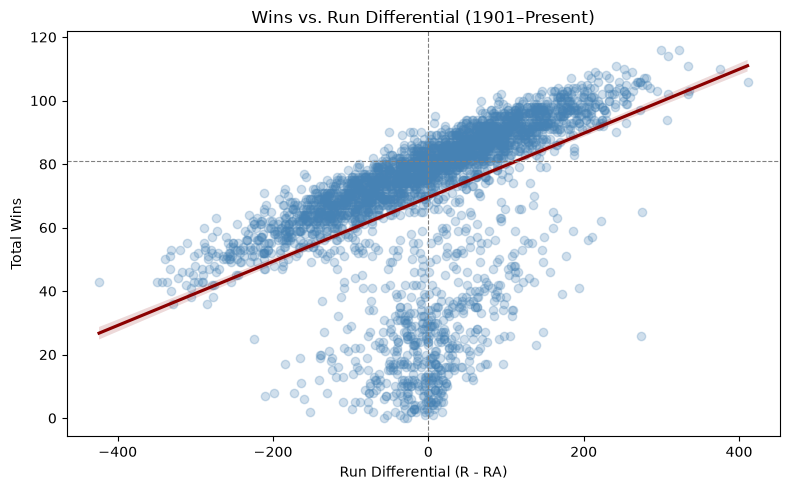

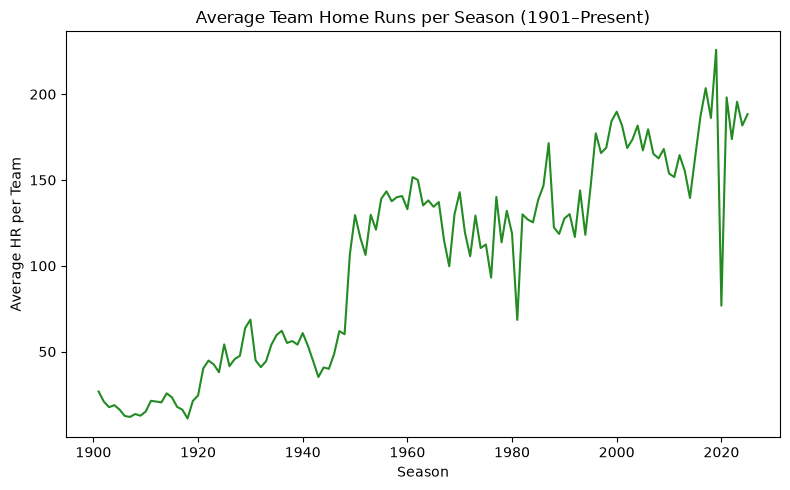

,yearID,name,W,L,WinPct,RunDiff,WSWin
493,1906,Chicago Cubs,116,36,0.753,323,N
2888,2001,Seattle Mariners,116,46,0.716,300,N
2792,1998,New York Yankees,114,48,0.704,309,Y
3507,2022,Los Angeles Dodgers,111,51,0.685,334,N
1762,1954,Cleveland Indians,111,43,0.712,242,N
568,1909,Pittsburgh Pirates,110,42,0.714,252,Y
1066,1927,New York Yankees,110,44,0.71,376,Y
2027,1969,Baltimore Orioles,109,53,0.673,262,N
1880,1961,New York Yankees,109,53,0.669,215,Y
2051,1970,Baltimore Orioles,108,54,0.667,218,Y


In [8]:
# 1. Run Differential vs. Wins
plt.figure(figsize=(8, 5))
sns.regplot(
    data=modern_teams,
    x="RunDiff",
    y="W",
    scatter_kws={"alpha": 0.25, "color": "steelblue"},
    line_kws={"color": "darkred"},
)
plt.axhline(81, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.title("Wins vs. Run Differential (1901–Present)")
plt.xlabel("Run Differential (R - RA)")
plt.ylabel("Total Wins")
plt.tight_layout()
plt.show()

# 2. League-wide Home Run Evolution
hr_trend = modern_teams.groupby("yearID")["HR"].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.lineplot(data=hr_trend, x="yearID", y="HR", color="forestgreen")
plt.title("Average Team Home Runs per Season (1901–Present)")
plt.xlabel("Season")
plt.ylabel("Average HR per Team")
plt.tight_layout()
plt.show()

# 3. Top 10 Single-Season Win Totals
top_10 = modern_teams.sort_values(by="W", ascending=False)[
    ["yearID", "name", "W", "L", "WinPct", "RunDiff", "WSWin"]
].head(10)

top_10

In [9]:
# 1. Clean missing values in postseason indicator flags
div_win = modern_teams["DivWin"].fillna("N") == "Y"
wc_win = modern_teams["WCWin"].fillna("N") == "Y"

# Filter to modern division/playoff era (1969+), exclude 1994
playoffs = modern_teams[
    (modern_teams["yearID"] >= 1969)
    & (modern_teams["yearID"] != 1994)
    & (div_win | wc_win)
].copy()

# 2. Target and feature engineering
playoffs["WS_Winner"] = (
    playoffs["WSWin"].fillna("N").apply(lambda x: 1 if x == "Y" else 0)
)
playoffs["R_per_G"] = playoffs["R"] / playoffs["G"]
playoffs["RA_per_G"] = playoffs["RA"] / playoffs["G"]
playoffs["HR_per_G"] = playoffs["HR"] / playoffs["G"]

features = ["WinPct", "RunDiff", "ERA", "HR_per_G", "R_per_G", "RA_per_G"]
target = "WS_Winner"

playoffs = playoffs.dropna(subset=features + [target])

# 3. Temporal Train/Test split: Train on 1969–2010, Test on 2011–present
train = playoffs[playoffs["yearID"] <= 2010].copy()
test = playoffs[playoffs["yearID"] > 2010].copy()

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# 4. Fit Logistic Regression pipeline
model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(class_weight="balanced", random_state=42)),
    ]
)
model.fit(X_train, y_train)

# 5. Predict probabilities
test["pred_prob"] = model.predict_proba(X_test)[:, 1]

# Postseason discrimination metric
test_auc = roc_auc_score(y_test, test["pred_prob"])
print(f"Postseason Test ROC-AUC: {test_auc:.3f}")

Postseason Test ROC-AUC: 0.587


In [10]:
# Identify the team with the highest modeled probability for each season
predicted_champs = (
    test.sort_values(["yearID", "pred_prob"], ascending=[True, False])
    .groupby("yearID")
    .first()
    .reset_index()
)

results_table = predicted_champs[
    ["yearID", "name", "pred_prob", "WS_Winner"]
].rename(
    columns={
        "yearID": "Year",
        "name": "Predicted Favorite",
        "pred_prob": "Win Probability",
        "WS_Winner": "Actually Won WS",
    }
)

correct_picks = results_table["Actually Won WS"].sum()
total_seasons = len(results_table)

print(
    f"Favorite Pick Accuracy: {correct_picks}/{total_seasons} ({correct_picks / total_seasons:.1%})\n"
)
results_table

Favorite Pick Accuracy: 1/15 (6.7%)



,Year,Predicted Favorite,Win Probability,Actually Won WS
0,2011,Philadelphia Phillies,0.721323,0
1,2012,Cincinnati Reds,0.581789,0
2,2013,St. Louis Cardinals,0.650349,0
3,2014,Washington Nationals,0.591542,0
4,2015,St. Louis Cardinals,0.686789,0
5,2016,Chicago Cubs,0.686051,1
6,2017,Cleveland Indians,0.694806,0
7,2018,Houston Astros,0.727367,0
8,2019,Houston Astros,0.597847,0
9,2020,Cleveland Indians,0.528052,0
